In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# clustering imports
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    OPTICS
)
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import OPTICS


In [14]:
#Bruiteforcing the parameters
df = pd.read_excel("receipts.xlsx")

numeric_cols = ["Paid Amount", "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"]
feature_set = [
    "Paid Amount", "is delivery", "is_morning", "is_afternoon", "is_evening",
    "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
X = df_scaled[feature_set].values

min_samples_list = [2, 5, 10]
xi_list = [0.05, 0.1, 0.5, 0.8]
min_cluster_size_list = [0.05]

results = []
for ms in min_samples_list:
    for xi in xi_list:
        for mcs in min_cluster_size_list:
            optics = OPTICS(min_samples=ms, xi=xi, min_cluster_size=mcs)
            labels = optics.fit_predict(X)
            n_noise = np.sum(labels == -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters > 1:
                sil = silhouette_score(X[labels != -1], labels[labels != -1])
            else:
                sil = np.nan
            results.append({
                "min_samples": ms,
                "xi": xi,
                "min_cluster_size": mcs,
                "silhouette_score": sil,
                "n_noise": n_noise,
                "n_clusters": n_clusters
            })

results_df = pd.DataFrame(results)

silhouette_df = results_df.pivot_table(index='xi', columns='min_samples', values='silhouette_score')
n_noise_df = results_df.pivot_table(index='xi', columns='min_samples', values='n_noise')
n_clusters_df = results_df.pivot_table(index='xi', columns='min_samples', values='n_clusters')

import ace_tools_open

print("Silhouette score:")
ace_tools_open.display_dataframe_to_user("Silhouette Score Table", silhouette_df)
print("Noise:")
ace_tools_open.display_dataframe_to_user("N Noise Table", n_noise_df)
print("Clusters:")
ace_tools_open.display_dataframe_to_user("N Clusters Table", n_clusters_df)

display(silhouette_df)
display(n_noise_df)
display(n_clusters_df)


Silhouette score:
Silhouette Score Table


Noise:
N Noise Table


Clusters:
N Clusters Table


min_samples,2,5,10
xi,,,
0.05,0.790121,0.785881,0.794358
0.10,0.810522,0.810902,0.816014
0.50,0.964056,0.964056,0.964056


min_samples,2,5,10
xi,,,
0.05,6608.0,6598.0,6619.0
0.10,7216.0,7217.0,7228.0
0.50,9140.0,9140.0,9140.0
0.80,10461.0,10461.0,10461.0


min_samples,2,5,10
xi,,,
0.05,7.0,7.0,7.0
0.10,6.0,6.0,6.0
0.50,2.0,2.0,2.0
0.80,1.0,1.0,1.0


    model  n_clusters  silhouette
0  OPTICS           7    0.794358

Best model by silhouette: OPTICS


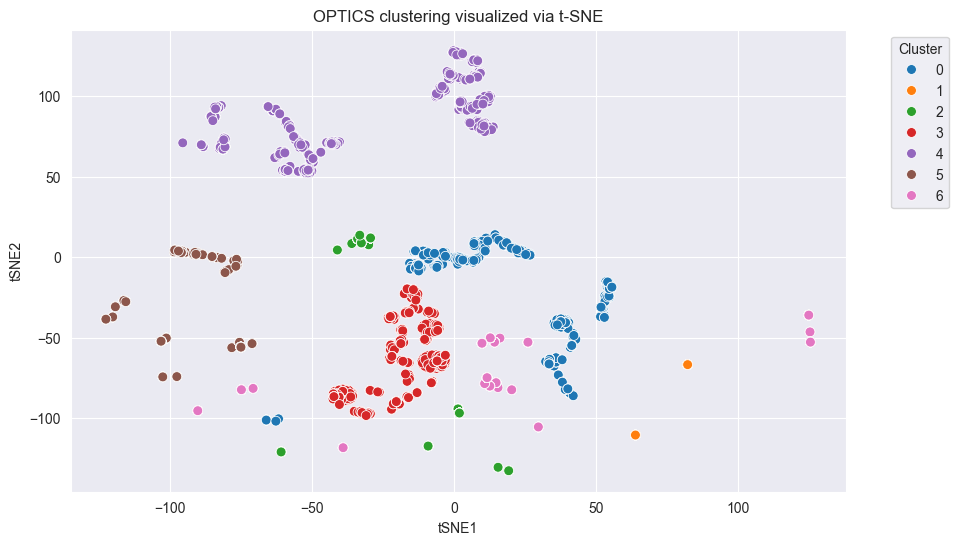

In [6]:
#Calculating of Silhouette score and plotting t-SNE for OPTICS for 7 clusters without noise
numeric_cols = ["Paid Amount", "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
feature_cols = [
    "Paid Amount", "is delivery",
    "is_morning", "is_afternoon", "is_evening",
    "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
]
X = df[feature_cols].values

models = {
    "OPTICS": OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05 ),
}

results = []

for name, model in models.items():
    if name.startswith("KPrototypes"):
        cat_idx = [feature_cols.index(c) for c in ["is delivery", "is_morning", "is_afternoon", "is_evening"]]
        labels = model.fit_predict(df[feature_cols].to_numpy(), categorical=cat_idx)
    elif name in ("GMM",):
        model.fit(X)
        labels = model.predict(X)
    else:
        labels = model.fit_predict(X)
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan
    results.append({"model": name, "n_clusters": len(set(labels)) - (1 if -1 in labels else 0), "silhouette": sil})

res_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
print(res_df)

best = res_df.iloc[0]["model"]
print(f"\nBest model by silhouette: {best}")


df["Cluster"] = labels
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_proj = tsne.fit_transform(X)
df["tSNE1"], df["tSNE2"] = tsne_proj[:, 0], tsne_proj[:, 1]
df = df[df['Cluster'] != -1]
plt.figure(figsize=(10, 6))
sns.scatterplot(x="tSNE1", y="tSNE2", hue="Cluster",
                palette="tab10", data=df, legend="full", s=50)
plt.title(f"{best} clustering visualized via t-SNE")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


    model  n_clusters  silhouette
0  OPTICS           7    0.794358
1  OPTICS           7    0.794358

Best model by silhouette: OPTICS


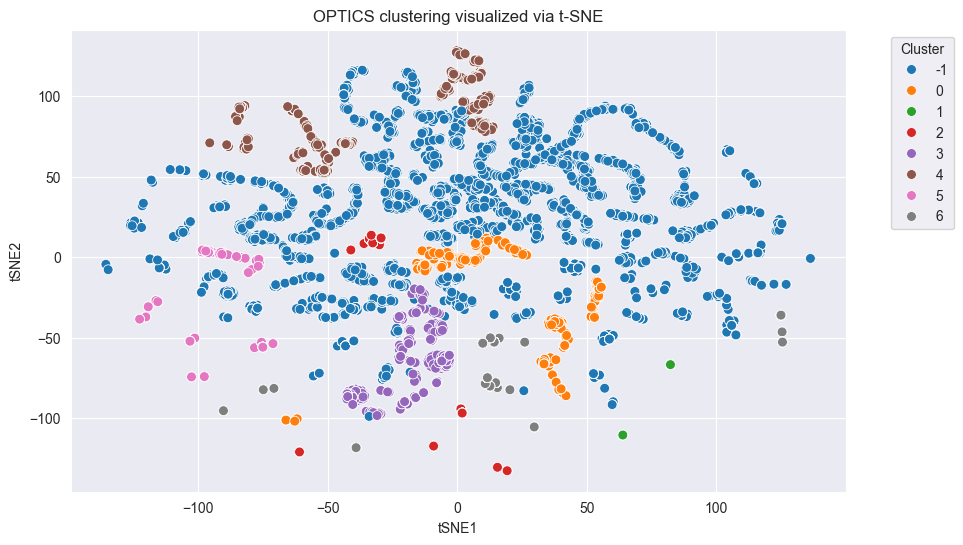

In [10]:
#Calculating of Silhouette score and plotting t-SNE for OPTICS for 7 clusters with noise
for name, model in models.items():
    if name.startswith("KPrototypes"):
        cat_idx = [feature_cols.index(c) for c in ["is delivery", "is_morning", "is_afternoon", "is_evening"]]
        labels = model.fit_predict(df[feature_cols].to_numpy(), categorical=cat_idx)
    elif name in ("GMM",):
        model.fit(X)
        labels = model.predict(X)
    else:
        labels = model.fit_predict(X)
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan
    results.append({"model": name, "n_clusters": len(set(labels)) - (1 if -1 in labels else 0), "silhouette": sil})

res_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
print(res_df)

best = res_df.iloc[0]["model"]
print(f"\nBest model by silhouette: {best}")

df["Cluster"] = labels

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_proj = tsne.fit_transform(X)
df["tSNE1"], df["tSNE2"] = tsne_proj[:, 0], tsne_proj[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x="tSNE1", y="tSNE2", hue="Cluster", palette="tab10", data=df, legend="full", s=50)
plt.title(f"{best} clustering visualized via t-SNE")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [12]:
#Computing metrix: silhouette score, calinski harabasz, davies bouldin
df = pd.read_excel("receipts.xlsx")
numeric_cols = ["Paid Amount", "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
feature_cols = [
    "Paid Amount", "is delivery",
    "is_morning", "is_afternoon", "is_evening",
    "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
]
X = df[feature_cols].values

models = {
    "OPTICS": OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05),
}

results = []

for name, model in models.items():
    labels = model.fit_predict(X)
    mask = labels != -1
    X_eval = X[mask] if name in ("DBSCAN", "OPTICS") else X
    labels_eval = labels[mask] if name in ("DBSCAN", "OPTICS") else labels
    
    if len(set(labels_eval)) > 1:
        sil = silhouette_score(X_eval, labels_eval)
        ch  = calinski_harabasz_score(X_eval, labels_eval)
        db  = davies_bouldin_score(X_eval, labels_eval)
    else:
        sil = ch = db = np.nan
    
    results.append({
        "Method": name,
        "Silhouette Score": sil,
        "Calinski Harabasz Score": ch,
        "Davies Bouldin Score": db
    })

res_df = pd.DataFrame(results)
res_df = res_df.set_index("Method").round(2)

res_df = res_df.sort_values("Silhouette Score", ascending=False)
print(res_df)


        Silhouette Score  Calinski Harabasz Score  Davies Bouldin Score
Method                                                                 
OPTICS              0.79                 12076.04                  0.39


In [24]:
#Calculation of min,max,mean,median for rescaled data
numeric_cols = [
    "Paid Amount",
    "ratio_kebab",
    "ratio_combo",
    "ratio_drink",
    "ratio_other"
]

feature_sets = {
    "set1": [
        "Paid Amount", "is delivery",
        "is_morning", "is_afternoon", "is_evening",
        "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
    ]
}

def reverse_scaling(df_scaled: pd.DataFrame,
                    numeric_cols: list[str],
                    scaler: StandardScaler) -> pd.DataFrame:
    
    df_rescaled = df_scaled.copy()
    inv_vals = scaler.inverse_transform(df_scaled[numeric_cols])
    df_rescaled[numeric_cols] = pd.DataFrame(
        inv_vals,
        index=df_scaled.index,
        columns=numeric_cols
    )
    return df_rescaled

df = pd.read_excel("receipts.xlsx")

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

X = df_scaled[feature_sets["set1"]].values
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
labels = optics.fit_predict(X)

df_scaled["Cluster"] = labels

df_rescaled = reverse_scaling(df_scaled, numeric_cols, scaler)

cluster_stats_by_set: dict[str, pd.DataFrame] = {}

for set_name, feats in feature_sets.items():
    missing = [f for f in feats if f not in df_rescaled.columns]
    if missing:
        raise KeyError(f"The following features are missing from df_rescaled: {missing}")
    
    
    stats = (
        df_rescaled
          .groupby("Cluster")[feats]
          .agg(["min", "max", "mean", "median"])
    )

    stats["Count"] = df_rescaled.groupby("Cluster").size().sort_index()
    
    cluster_stats_by_set[set_name] = stats

for set_name, stats in cluster_stats_by_set.items():
    print(f"\nCluster statistics for feature-set '{set_name}':\n")
    print(stats)

stats



Cluster statistics for feature-set 'set1':

        Paid Amount                             is delivery                \
                min      max        mean median         min max      mean   
Cluster                                                                     
-1              5.0  1727.00  260.165114  224.0           0   1  0.106512   
 0            135.0   521.00  214.113003  182.0           0   0  0.000000   
 1            155.0   157.00  156.626134  157.0           0   0  0.000000   
 2            140.0   151.00  144.546751  145.0           0   0  0.000000   
 3            172.0   248.00  201.210526  194.0           0   0  0.000000   
 4            160.0   924.89  342.622752  294.0           0   1  0.281600   
 5             27.0   204.00   46.895018   37.0           0   0  0.000000   
 6            140.0   162.00  151.231250  151.0           0   0  0.000000   

               is_morning      ... ratio_combo ratio_drink            \
        median        min max  ... 

Paid Amount                             is delivery                \
                min      max        mean median         min max      mean   
Cluster                                                                     
-1              5.0  1727.00  260.165114  224.0           0   1  0.106512   
 0            135.0   521.00  214.113003  182.0           0   0  0.000000   
 1            155.0   157.00  156.626134  157.0           0   0  0.000000   
 2            140.0   151.00  144.546751  145.0           0   0  0.000000   
 3            172.0   248.00  201.210526  194.0           0   0  0.000000   
 4            160.0   924.89  342.622752  294.0           0   1  0.281600   
 5             27.0   204.00   46.895018   37.0           0   0  0.000000   
 6            140.0   162.00  151.231250  151.0           0   0  0.000000   

               is_morning      ... ratio_combo ratio_drink            \
        median        min max  ...      median         min       max   
Cluster                        ...                                     
-1         0.0          0   1  ...     0.00000    0.000000  1.000000   
 0         0.0          1   1  ...     0.00000    0.000000  0.363208   
 1         0.0          0   0  ...     0.00000    0.000000  0.000000   
 2         0.0          0   0  ...     0.00000    0.000000  0.000000   
 3         0.0          0   0  ...     0.00000    0.145228  0.228571   
 4         0.0          0   0  ...     0.94023    0.000000  0.192513   
 5         0.0          0   0  ...     0.00000    1.000000  1.000000   
 6         0.0          0   0  ...     0.00000    0.000000  0.000000   

                            ratio_other                            Count  
             mean    median         min       max      mean median        
Cluster                                                                   
-1       0.132151  0.000000         0.0  1.000000  0.162930    0.0  6619  
 0       0.057430  0.000000         0.0  0.000000  0.000000    0.0   646  
 1       0.000000  0.000000         0.0  0.000000  0.000000    0.0   551  
 2       0.000000  0.000000         0.0  0.000000  0.000000    0.0   631  
 3       0.186648  0.190722         0.0  0.000000  0.000000    0.0   589  
 4       0.008031  0.000000         0.0  0.565916  0.054963    0.0   625  
 5       1.000000  1.000000         0.0  0.000000  0.000000    0.0   562  
 6       0.000000  0.000000         0.0  0.000000  0.000000    0.0   800  

[8 rows x 37 columns]